In [184]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report

In [185]:
telco_df = pd.read_csv('Telco-Customer-Churn.csv')

In [186]:
telco_df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [187]:
telco_df.select_dtypes(exclude='object').columns

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges'], dtype='str')

In [188]:
telco_df.select_dtypes(include='str').columns

Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges',
       'Churn'],
      dtype='str')

In [189]:
numeric_columns = ['SeniorCitizen', 'tenure', 'MonthlyCharges'] #all are numeric
object_columns = ['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges',
       'Churn']

In [190]:
telco_df.isna().sum() #no missing values

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [191]:
telco_df.describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.0,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.0,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75


In [192]:
telco_df[numeric_columns].head()

,SeniorCitizen,tenure,MonthlyCharges
0,0,1,29.85
1,0,34,56.95
2,0,2,53.85
3,0,45,42.30
4,0,2,70.70


In [193]:
telco_df[numeric_columns].head()

,SeniorCitizen,tenure,MonthlyCharges
0,0,1,29.85
1,0,34,56.95
2,0,2,53.85
3,0,45,42.30
4,0,2,70.70


In [194]:
(telco_df[object_columns].apply(lambda col: col.str.strip() == '')).sum()

customerID           0
gender               0
Partner              0
Dependents           0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
TotalCharges        11
Churn                0
dtype: int64

In [195]:
telco_df.shape #decided to drop missing values in str columns because we have 11 missing values which is 0.16% of dataset

(7043, 21)

In [196]:
telco_df['TotalCharges'] = pd.to_numeric(telco_df['TotalCharges'], errors='coerce')

telco_df[telco_df['TotalCharges'].isna()][['customerID', 'tenure', 'TotalCharges']]

telco_df = telco_df.dropna(subset=['TotalCharges']).reset_index(drop=True)

telco_df['TotalCharges'].isna().sum()

np.int64(0)

In [197]:
object_columns.remove('TotalCharges')
numeric_columns.append('TotalCharges')

In [198]:
telco_df.duplicated().sum()

np.int64(0)

In [199]:
telco_df['Churn'].value_counts(normalize=True)

Churn
No     0.734215
Yes    0.265785
Name: proportion, dtype: float64

In [200]:
telco_df[object_columns].nunique()

customerID          7032
gender                 2
Partner                2
Dependents             2
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
Churn                  2
dtype: int64

In [201]:
telco_df.drop(columns=['customerID'], inplace=True)

In [202]:
def find_outliers(numeric_column):
    Q1 = telco_df[numeric_column].quantile(0.25)
    Q3 = telco_df[numeric_column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = telco_df[(telco_df[numeric_column] < lower_bound) | (telco_df[numeric_column] > upper_bound)]
    print(outliers)

In [203]:
object_columns.remove('customerID')

numeric_columns = ['tenure', 'MonthlyCharges', 'TotalCharges']
binary_columns = ['SeniorCitizen']

for c in numeric_columns:
    find_outliers(c)

Empty DataFrame
Columns: [gender, SeniorCitizen, Partner, Dependents, tenure, PhoneService, MultipleLines, InternetService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies, Contract, PaperlessBilling, PaymentMethod, MonthlyCharges, TotalCharges, Churn]
Index: []
Empty DataFrame
Columns: [gender, SeniorCitizen, Partner, Dependents, tenure, PhoneService, MultipleLines, InternetService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies, Contract, PaperlessBilling, PaymentMethod, MonthlyCharges, TotalCharges, Churn]
Index: []
Empty DataFrame
Columns: [gender, SeniorCitizen, Partner, Dependents, tenure, PhoneService, MultipleLines, InternetService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies, Contract, PaperlessBilling, PaymentMethod, MonthlyCharges, TotalCharges, Churn]
Index: []


In [204]:
from sklearn.model_selection import train_test_split

telco_df['Churn'] = telco_df['Churn'].map({"Yes": 1, "No": 0})

categorical_columns = [c for c in object_columns if c != 'Churn']
telco_encoded = pd.get_dummies(telco_df, columns=categorical_columns, drop_first=True)

X = telco_encoded.drop(columns=['Churn'])
y = telco_encoded['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [205]:
telco_encoded.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


In [206]:
def show_metrics(y_test, y_pred):
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1:", f1_score(y_test, y_pred))
    print(confusion_matrix(y_test, y_pred))

In [207]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, \
    classification_report

knn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', KNeighborsClassifier(n_neighbors=5))
])
knn_pipeline.fit(X_train, y_train)
y_pred = knn_pipeline.predict(X_test)

In [208]:
def show_metrics(y_test, y_pred):
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1:", f1_score(y_test, y_pred))
    print(confusion_matrix(y_test, y_pred))

In [209]:
show_metrics(y_test, y_pred)

Accuracy: 0.7533759772565742
Precision: 0.5361930294906166
Recall: 0.5347593582887701
F1: 0.535475234270415
[[860 173]
 [174 200]]


__Results for knn with 5 n__

Accuracy: 0.7533759772565742
Precision: 0.5361930294906166
Recall: 0.5347593582887701
F1: 0.535475234270415
confusion matrix:
[[860 173]
 [174 200]]

In [210]:
param_grid_knn = {
    'model__n_neighbors': range(3, 101, 2),
    'model__weights': ['uniform', 'distance'],
    'model__p': [1, 2],
    'model__n_jobs': [-1]
}

In [211]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

grid = GridSearchCV(
    knn_pipeline,
    param_grid_knn,
    scoring='f1',
    cv=cv,
    n_jobs=-1
)

grid.fit(X_train, y_train)

print(grid.best_params_)
print(grid.best_score_)

{'model__n_jobs': -1, 'model__n_neighbors': 53, 'model__p': 2, 'model__weights': 'uniform'}
0.6040567309372118


In [212]:
y_pred = grid.predict(X_test)

report_knn = classification_report(y_test, y_pred, output_dict=True)

temp_data = {
    'model_type': grid.best_estimator_.named_steps['model'].__class__.__name__,
    'f1': report_knn['1']['f1-score'],
    'accuracy': report_knn['accuracy'],
    'precision': report_knn['1']['precision'],
    'recall': report_knn['1']['recall'],
    'hyperparameters': grid.best_params_
}

metrics_df = pd.DataFrame([temp_data])

In [213]:
metrics_df

,model_type,f1,accuracy,precision,recall,hyperparameters
0,KNeighborsClassifier,0.605263,0.78678,0.595855,0.614973,"{'model__n_jobs': -1, 'model__n_neighbors': 53..."


In [214]:
print("Best parameters:", grid.best_params_)
print("Best CV F1:", grid.best_score_)

best_knn = grid.best_estimator_
y_pred = best_knn.predict(X_test)

show_metrics(y_test, y_pred)

Best parameters: {'model__n_jobs': -1, 'model__n_neighbors': 53, 'model__p': 2, 'model__weights': 'uniform'}
Best CV F1: 0.6040567309372118
Accuracy: 0.7867803837953091
Precision: 0.5958549222797928
Recall: 0.6149732620320856
F1: 0.6052631578947368
[[877 156]
 [144 230]]


__KNN is not currently performing strongly enough for this problem, even after tuning, so I should investigate other model families.__

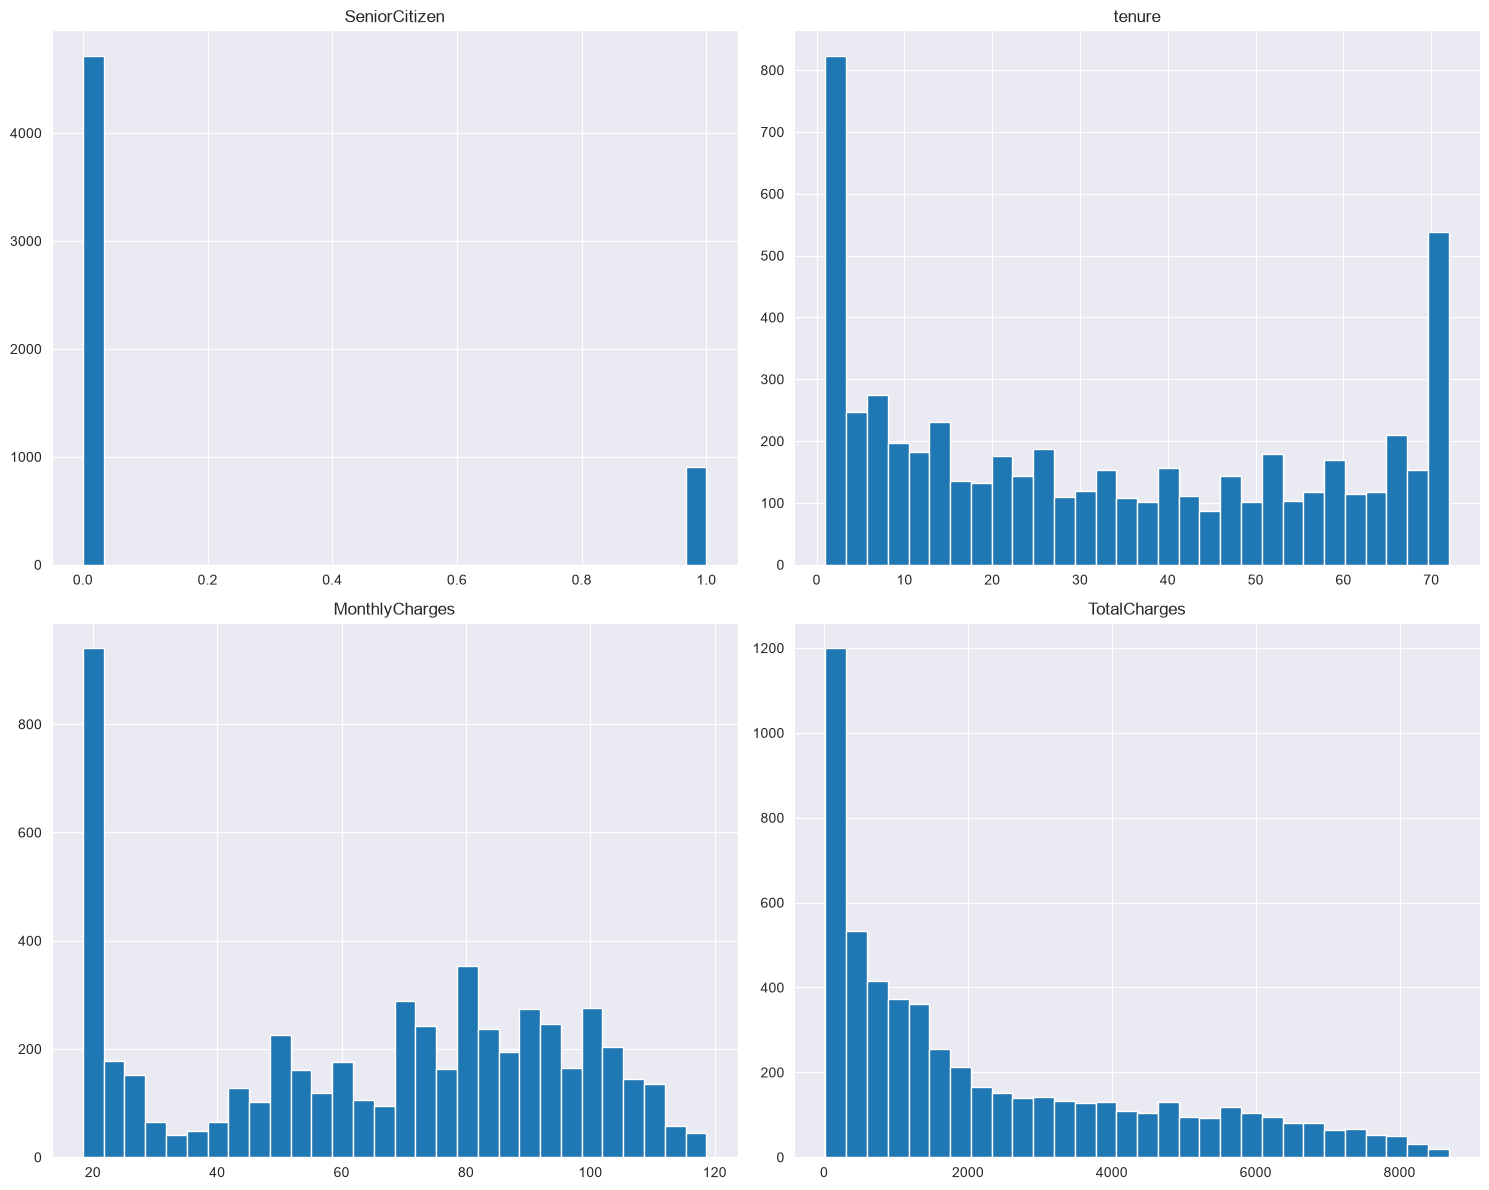

In [215]:
import matplotlib.pyplot as plt

X_train.hist(figsize=(15, 12), bins=30)
plt.tight_layout()
plt.show()

In [216]:
from sklearn.linear_model import LogisticRegression

lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression())
])

In [217]:
lr_pipeline.fit(X_train, y_train)

y_pred = lr_pipeline.predict(X_test)

show_metrics(y_test, y_pred)

Accuracy: 0.8038379530916845
Precision: 0.6475903614457831
Recall: 0.5748663101604278
F1: 0.6090651558073654
[[916 117]
 [159 215]]


In [218]:
param_grid_lr = [
    {
        'model__C': [0.001, 0.01, 0.1, 1, 10, 100],
        'model__penalty': ['l1', 'l2'],
        'model__solver': ['liblinear']
    },
    {
        'model__C': [0.001, 0.01, 0.1, 1, 10, 100],
        'model__penalty': ['l2'],
        'model__solver': ['lbfgs']
    },
    {
        'model__C': [0.001, 0.01, 0.1, 1, 10, 100],
        'model__penalty': ['l1', 'l2', 'elasticnet'],
        'model__solver': ['saga'],
        'model__l1_ratio': [0.2, 0.5, 0.8]
    }
]

In [219]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

grid_lr = GridSearchCV(
    lr_pipeline,
    param_grid=param_grid_lr,
    cv=cv,
    scoring='f1',
    n_jobs=-1
)

grid_lr.fit(X_train, y_train)

print("Best parameters:", grid_lr.best_params_)
print("Best CV F1:", grid_lr.best_score_)

y_pred = grid_lr.best_estimator_.predict(X_test)

show_metrics(y_test, y_pred)

Best parameters: {'model__C': 0.001, 'model__penalty': 'l2', 'model__solver': 'liblinear'}
Best CV F1: 0.628180110646326
Accuracy: 0.7960199004975125
Precision: 0.6023529411764705
Recall: 0.6844919786096256
F1: 0.6408010012515645
[[864 169]
 [118 256]]


C:\Users\user\Desktop\MlLibraries\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


In [220]:
report_lr = classification_report(y_test, y_pred, output_dict=True)

lr_data = {
    'model_type': grid_lr.best_estimator_.named_steps['model'].__class__.__name__,
    'f1': report_lr['1']['f1-score'],
    'accuracy': report_lr['accuracy'],
    'precision': report_lr['1']['precision'],
    'recall': report_lr['1']['recall'],
    'hyperparameters': grid_lr.best_params_
}
metrics_df.loc[len(metrics_df)] = lr_data

In [221]:
metrics_df.loc[len(metrics_df)] = lr_data
metrics_df

,model_type,f1,accuracy,precision,recall,hyperparameters
0,KNeighborsClassifier,0.605263,0.78678,0.595855,0.614973,"{'model__n_jobs': -1, 'model__n_neighbors': 53..."
1,LogisticRegression,0.640801,0.79602,0.602353,0.684492,"{'model__C': 0.001, 'model__penalty': 'l2', 'm..."
2,LogisticRegression,0.640801,0.79602,0.602353,0.684492,"{'model__C': 0.001, 'model__penalty': 'l2', 'm..."


__The results became better compared to knn but i still should try to fix class imbalance and try to apply it for knn and lr before moving to svm__

In [222]:
from imblearn.over_sampling import SMOTE, ADASYN

smote = SMOTE()

X_resampled_smote, y_resampled_smote = smote.fit_resample(X_train, y_train)

smote_knn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', KNeighborsClassifier())
])

smote_lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression())
])

In [223]:
y_resampled_smote.value_counts()

Churn
0    4130
1    4130
Name: count, dtype: int64

In [224]:
smote_knn_grid = GridSearchCV(
    smote_knn_pipeline,
    param_grid_knn,
    cv=cv,
    scoring='f1',
    n_jobs=-1
)

smote_knn_grid.fit(X_resampled_smote, y_resampled_smote)
print(smote_knn_grid.best_score_)
print(smote_knn_grid.best_estimator_)

0.8256537045592809
Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 KNeighborsClassifier(n_jobs=-1, n_neighbors=13, p=1,
                                      weights='distance'))])


In [225]:
y_pred_knn_smote = smote_knn_grid.predict(X_test)

show_metrics(y_test, y_pred_knn_smote)

Accuracy: 0.7221037668798863
Precision: 0.4835589941972921
Recall: 0.6684491978609626
F1: 0.5611672278338945
[[766 267]
 [124 250]]


In [226]:
report_knn_smote = classification_report(y_test, y_pred_knn_smote, output_dict=True)

knn_smote_data = {
    'model_type': smote_knn_grid.best_estimator_.named_steps['model'].__class__.__name__ + " SMOTE",
    'f1': report_knn_smote['1']['f1-score'],
    'accuracy': report_knn_smote['accuracy'],
    'precision': report_knn_smote['1']['precision'],
    'recall': report_knn_smote['1']['recall'],
    'hyperparameters': smote_knn_grid.best_params_
}
metrics_df.loc[len(metrics_df)] = knn_smote_data

In [227]:
smote_lr_grid = GridSearchCV(
    smote_lr_pipeline,
    param_grid_lr,
    cv=cv,
    scoring='f1',
    n_jobs=-1
)

smote_lr_grid.fit(X_resampled_smote, y_resampled_smote)

C:\Users\user\Desktop\MlLibraries\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...egression())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'model__C': [0.001, 0.01, ...], 'model__penalty': ['l1', 'l2'], 'model__solver': ['liblinear']}, {'model__C': [0.001, 0.01, ...], 'model__penalty': ['l2'], 'model__solver': ['lbfgs']}, ...]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplex

In [228]:
y_pred_lr_smote = smote_lr_grid.predict(X_test)

show_metrics(y_test, y_pred_lr_smote)

Accuracy: 0.7604832977967306
Precision: 0.5427251732101617
Recall: 0.6283422459893048
F1: 0.5824039653035935
[[835 198]
 [139 235]]


In [229]:
report_lr_smote = classification_report(y_test, y_pred_lr_smote, output_dict=True)

lr_smote_data = {
    'model_type': smote_lr_grid.best_estimator_.named_steps['model'].__class__.__name__ + " SMOTE",
    'f1': report_lr_smote['1']['f1-score'],
    'accuracy': report_lr_smote['accuracy'],
    'precision': report_lr_smote['1']['precision'],
    'recall': report_lr_smote['1']['recall'],
    'hyperparameters': smote_lr_grid.best_params_
}
metrics_df.loc[len(metrics_df)] = lr_smote_data

In [230]:
metrics_df.sort_values('f1', ascending=False)

,model_type,f1,accuracy,precision,recall,hyperparameters
1,LogisticRegression,0.640801,0.796020,0.602353,0.684492,"{'model__C': 0.001, 'model__penalty': 'l2', 'm..."
2,LogisticRegression,0.640801,0.796020,0.602353,0.684492,"{'model__C': 0.001, 'model__penalty': 'l2', 'm..."
0,KNeighborsClassifier,0.605263,0.786780,0.595855,0.614973,"{'model__n_jobs': -1, 'model__n_neighbors': 53..."
4,LogisticRegression SMOTE,0.582404,0.760483,0.542725,0.628342,"{'model__C': 100, 'model__penalty': 'l2', 'mod..."
3,KNeighborsClassifier SMOTE,0.561167,0.722104,0.483559,0.668449,"{'model__n_jobs': -1, 'model__n_neighbors': 13..."


In [231]:
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline([
    ('model', RandomForestClassifier(class_weight='balanced', random_state=42))
])

param_grid_rf = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [5, 10, 15, None],
    'model__min_samples_split': [2, 5, 10]
}

grid_rf = GridSearchCV(
    rf_pipeline,
    param_grid_rf,
    cv=cv,
    scoring='f1',
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

y_pred_rf = grid_rf.best_estimator_.predict(X_test)
show_metrics(y_test, y_pred_rf)

report_rf = classification_report(y_test, y_pred_rf, output_dict=True)
rf_data = {
    'model_type': 'RandomForest',
    'f1': report_rf['1']['f1-score'],
    'accuracy': report_rf['accuracy'],
    'precision': report_rf['1']['precision'],
    'recall': report_rf['1']['recall'],
    'hyperparameters': grid_rf.best_params_
}
metrics_df.loc[len(metrics_df)] = rf_data
metrics_df.sort_values('f1', ascending=False)

Accuracy: 0.7491115849324804
Precision: 0.5184534270650264
Recall: 0.7887700534759359
F1: 0.6256627783669141
[[759 274]
 [ 79 295]]


,model_type,f1,accuracy,precision,recall,hyperparameters
1,LogisticRegression,0.640801,0.796020,0.602353,0.684492,"{'model__C': 0.001, 'model__penalty': 'l2', 'm..."
2,LogisticRegression,0.640801,0.796020,0.602353,0.684492,"{'model__C': 0.001, 'model__penalty': 'l2', 'm..."
5,RandomForest,0.625663,0.749112,0.518453,0.788770,"{'model__max_depth': 10, 'model__min_samples_s..."
0,KNeighborsClassifier,0.605263,0.786780,0.595855,0.614973,"{'model__n_jobs': -1, 'model__n_neighbors': 53..."
4,LogisticRegression SMOTE,0.582404,0.760483,0.542725,0.628342,"{'model__C': 100, 'model__penalty': 'l2', 'mod..."
3,KNeighborsClassifier SMOTE,0.561167,0.722104,0.483559,0.668449,"{'model__n_jobs': -1, 'model__n_neighbors': 13..."
